<a href="https://colab.research.google.com/github/daviseemann/turbofan-rul-prediction-cmapss/blob/production/notebooks/MLP-3-lr-w-tunning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount(
    "/content/drive/",
)
import os

os.chdir(
    "/content/drive/MyDrive/Data science studies/Aprendizado-de-maquina-UFSC/final-project/data"
)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [87]:
# Caminhos dos arquivos
train_path = "./6.turbofan rul/train_FD001.txt"
test_path = "./6.turbofan rul/test_FD001.txt"
rul_path = "./6.turbofan rul/RUL_FD001.txt"

# Nomes das colunas (de acordo com a documentação original do C-MAPSS)
column_names = (
    ["engine_id", "cycle"]
    + [f"op{i}" for i in range(1, 4)]
    + [f"s{i}" for i in range(1, 22)]
)

# Importando os arquivos (espaço em branco como delimitador)
df_train_raw = pd.read_csv(train_path, sep="\s+", header=None, names=column_names)
df_test = pd.read_csv(test_path, sep="\s+", header=None, names=column_names)
df_rul = pd.read_csv(rul_path, sep="\s+", header=None, names=["RUL"])

In [88]:
display(df_train_raw.head())
display(df_test.head())
display(df_rul.head())

,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


,RUL
0,112
1,98
2,69
3,82
4,91


In [89]:
selected_sensors = [
    "s2",
    "s3",
    "s4",
    "s7",
    "s8",
    "s9",
    "s11",
    "s12",
    "s13",
    "s14",
    "s15",
    "s17",
    "s20",
    "s21",
]

# Specify the engine ID you want to visualize
engine_id_to_plot = 1

# Filter the DataFrame for the selected engine ID
engine_data = df_train_raw[df_train_raw['engine_id'] == engine_id_to_plot]

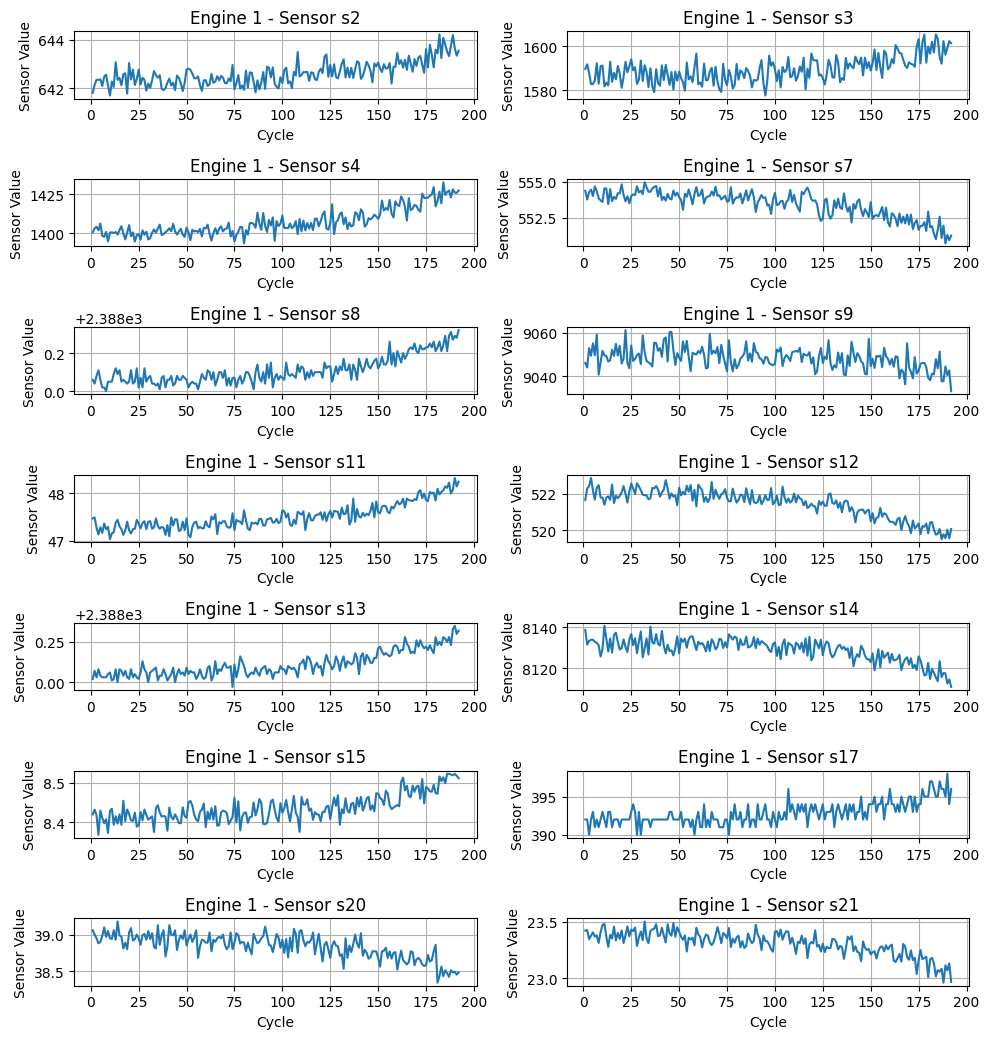

In [90]:
# Determine the number of rows needed for a 2-column layout
n_sensors = len(selected_sensors)
n_cols = 2
n_rows = (n_sensors + n_cols - 1) // n_cols  # Ceiling division

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 1.5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Plot each sensor
for i, sensor in enumerate(selected_sensors):
    ax = axes[i]
    ax.plot(engine_data['cycle'], engine_data[sensor])
    ax.set_title(f'Engine {engine_id_to_plot} - Sensor {sensor}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Sensor Value')
    ax.grid(True)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Pré-processamento


### Seleção de Sensores

O artigo menciona que apenas 14 dos 21 sensores são usados. Vamos selecionar os mesmos:


In [91]:
# Sensores selecionados conforme o artigo
selected_sensors = [
    "s2",
    "s3",
    "s4",
    "s7",
    "s8",
    "s9",
    "s11",
    "s12",
    "s13",
    "s14",
    "s15",
    "s17",
    "s20",
    "s21",
]

# Colunas que vamos manter
features_to_keep = ["engine_id", "cycle"] + selected_sensors

# Filtrando os dataframes
df_train_raw = df_train_raw[features_to_keep]
df_test = df_test[features_to_keep]

### Criando os RULs para Treino

O artigo usa um modelo de degradação linear por partes com RUL constante inicial (Re):


In [92]:
def create_rul_labels(df, Re, clip_at_zero=True):
    """Cria os rótulos RUL usando o modelo de degradação linear por partes"""
    grouped = df.groupby("engine_id")["cycle"].max().reset_index()
    grouped.columns = ["engine_id", "max_cycle"]

    df = df.merge(grouped, on="engine_id", how="left")
    df["RUL"] = df["max_cycle"] - df["cycle"]

    # Aplica o modelo de degradação linear por partes
    df["RUL"] = np.where(df["RUL"] > Re, Re, df["RUL"])

    return df.drop(columns=["max_cycle"])

# Usando Re=128 conforme sugerido no artigo para FD001
Re = 128
df_train_raw = create_rul_labels(df_train_raw, Re)

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_rul_by_engine(df, engines_to_plot=5):
    """Plota o RUL ao longo do tempo para algumas engines"""
    # Selecionar engines para visualizar
    engine_ids = df["engine_id"].unique()[:engines_to_plot]

    plt.figure(figsize=(8, 6))

    for engine_id in engine_ids:
        engine_data = df[df["engine_id"] == engine_id]
        plt.plot(engine_data["cycle"], engine_data["RUL"], label=f'Engine {engine_id}')

    plt.xlabel('Cycle')
    plt.ylabel('RUL')
    plt.title('RUL por Engine ID')
    plt.legend()
    plt.grid(True)
    plt.show()


### Preparando as Janelas Temporais

O artigo usa janelas temporais com tamanho (nw) e stride (ns):


separando os dados de validação e treino

In [95]:
from sklearn.model_selection import train_test_split

unique_engines = np.unique(df_train_raw['engine_id'])
train_engines, val_engines = train_test_split(unique_engines, test_size=0.2, shuffle=False)

df_train = df_train_raw[df_train_raw['engine_id'].isin(train_engines)]
df_val = df_train_raw[df_train_raw['engine_id'].isin(val_engines)]
display(train_engines, df_train.shape)
display(val_engines, df_val.shape)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80])

(16138, 17)

array([ 81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,
        94,  95,  96,  97,  98,  99, 100])

(4493, 17)

In [96]:
def create_time_windows(df, window_size, window_stride, sensor_cols):
    """Cria janelas temporais dos dados dos sensores e retorna um DataFrame com info da janela"""
    sequences = []
    labels = []
    engine_ids = []
    last_cycles = []

    for engine_id in df["engine_id"].unique():
        engine_data = df[df["engine_id"] == engine_id]
        sensor_data = engine_data[sensor_cols].values
        rul_data = engine_data["RUL"].values

        # Cria janelas deslizantes
        for i in range(0, len(engine_data) - window_size + 1, window_stride):
            window = sensor_data[i: i + window_size]
            label = rul_data[i + window_size - 1]
            sequences.append(window)
            labels.append(label)
            engine_ids.append(engine_id)
            last_cycles.append(engine_data["cycle"].iloc[i + window_size - 1])

    # Flatten sequences for MLP input
    n_samples = len(sequences)
    n_timesteps = window_size
    n_features = len(sensor_cols)
    flattened_sequences = np.array(sequences).reshape((n_samples, n_timesteps * n_features))

    df_windows = pd.DataFrame({
        'engine_id': engine_ids,
        'last_cycle': last_cycles,
        'data_vector': list(flattened_sequences),
        'RUL': labels
    })

    return df_windows

In [97]:
# Parâmetros do artigo para FD001: nw=24, ns=1
window_size = 24
window_stride = 1

# Criando as sequências de treino
sensor_cols = selected_sensors
df_train_windows = create_time_windows(df_train, window_size, window_stride, sensor_cols)

# Criando as sequências de validação
df_val_windows = create_time_windows(df_val, window_size, window_stride, sensor_cols)

# Separando X_train e y_train
X_train = np.array(list(df_train_windows['data_vector']))
y_train = df_train_windows['RUL'].values

# Separando X_val e y_val
X_val = np.array(list(df_val_windows['data_vector']))
y_val = df_val_windows['RUL'].values
val_data= (X_val, y_val)


# Arquitetura da MLP

In [98]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Layer


def root_mean_squared_error(y_true, y_pred):
    # Converte os inputs para float32 explicitamente
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    squared_diff = tf.square(y_pred - y_true)
    mean_squared = tf.reduce_mean(squared_diff)
    rmse = tf.sqrt(mean_squared)
    return rmse


def rul_health_score(y_true, y_pred):
    # 1) Garante vetores 1D float32
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)

    d = y_pred - y_true

    score = tf.where(
        d < 0.0,
        tf.exp(-d / 13.0) - 1.0,
        tf.exp(d / 10.0) - 1.0
    )

    return tf.reduce_mean(score)


class MinMaxScalerLayer(Layer):
    def __init__(self, mins, denom, **kwargs):
        super().__init__(**kwargs)
        # Convert numpy arrays to TensorFlow tensors for saving
        self.mins = tf.constant(mins, dtype=tf.float32)
        self.denom = tf.constant(denom, dtype=tf.float32)


    def call(self, inputs):
        return 2.0 * (inputs - self.mins) / self.denom - 1.0

    def get_config(self):
        config = super().get_config()
        config.update({
            # Convert tensors back to numpy arrays for serialization
            "mins": self.mins.numpy().tolist(),
            "denom": self.denom.numpy().tolist(),
        })
        return config

In [99]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.metrics import MeanSquaredError, RootMeanSquaredError
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l1_l2


def create_mlp(input_dim, minmax_layer, lr=0.001, l1=0.1, l2=0.2):
    reg = l1_l2(l1=l1, l2=l2)

    model = Sequential(
        [
            Input(shape=(input_dim,)),
            minmax_layer,
            Dense(20, activation="relu",
                  kernel_regularizer=reg, bias_regularizer=reg),
            Dense(20, activation="relu",
                  kernel_regularizer=reg, bias_regularizer=reg),
            Dense(1, activation="linear",
                  kernel_regularizer=reg, bias_regularizer=reg),
        ],
        name="Arquitetura-1",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[
            MeanSquaredError(name="mse"),
            RootMeanSquaredError(name="rmse"),
            rul_health_score,
        ],
    )
    return model



# preparando os dados de teste

In [100]:
df_rul['engine_id'] = df_rul.index + 1
display(df_rul.head())

,RUL,engine_id
0,112,1
1,98,2
2,69,3
3,82,4
4,91,5


In [101]:
import numpy as np


# Supondo que df_rul tenha colunas ['engine_id', 'RUL']
df_rul = df_rul.rename(columns={'RUL':'true_RUL'})

# Geração das janelas e labels
X_test = []
y_test = []

for eid, group in df_test.groupby('engine_id', sort=False):
    data = group[sensor_cols].values
    # Pega só a última janela completa
    window = data[-window_size:]
    X_test.append(window.flatten())
    # Usa o RUL “verdadeiro” do df_rul
    y_test.append(
        df_rul.loc[df_rul['engine_id']==eid, 'true_RUL'].item()
    )

# Converte para arrays
X_test = np.stack(X_test)
y_test = np.array(y_test)


# Iterando sobre outros tamanhos de janela

In [103]:
from keras.callbacks import EarlyStopping
import itertools

In [104]:
BATCH_SIZE   = 128
N_EPOCHS     = 100
PATIENCE_ES  = 20
SEED_FIXED   = 42

In [109]:
# ------------------------------------------------------------------
# 2.  Função de treino recebendo lr
# ------------------------------------------------------------------
def train_full_and_test(X_train_full, y_train_full, X_test, y_test, lr: float):
    """Treina e avalia o MLP para um único (window, lr)."""
    X_train_np = np.stack(X_train_full['data_vector'].values).astype("float32")

    mins  = X_train_np.min(axis=0)
    denom = X_train_np.max(axis=0) - mins
    minmax_layer = MinMaxScalerLayer(mins, denom)

    model = create_mlp(input_dim=X_train_np.shape[1], minmax_layer=minmax_layer, lr=lr)

    model.fit(
        X_train_np, y_train_full,
        epochs      = N_EPOCHS,
        batch_size  = BATCH_SIZE,
        callbacks   =[EarlyStopping(patience=PATIENCE_ES,
                                    restore_best_weights=True,
                                    monitor="rhs")],
        verbose     = 0
    )

    X_test_np = np.asarray(X_test, dtype="float32")
    metrics   = model.evaluate(X_test_np, y_test, verbose=0, return_dict=True)
    return metrics["rmse"], metrics["rul_health_score"]

In [110]:
# ------------------------------------------------------------------
# 2.  Função de treino recebendo lr
# ------------------------------------------------------------------
def train_full_and_test(X_train_full, y_train_full, X_test, y_test, lr: float):
    """Treina e avalia o MLP para um único (window, lr)."""
    X_train_np = np.stack(X_train_full['data_vector'].values).astype("float32")

    mins  = X_train_np.min(axis=0)
    denom = X_train_np.max(axis=0) - mins
    minmax_layer = MinMaxScalerLayer(mins, denom)

    model = create_mlp(X_train_np.shape[1], minmax_layer, lr)

    model.fit(
        X_train_np, y_train_full,
        epochs      = N_EPOCHS,
        batch_size  = BATCH_SIZE,
        callbacks   =[EarlyStopping(patience=PATIENCE_ES,
                                    restore_best_weights=True,
                                    monitor="rmse")],
        verbose     = 0
    )

    X_test_np = np.asarray(X_test, dtype="float32")
    metrics   = model.evaluate(X_test_np, y_test, verbose=0, return_dict=True)
    return metrics["rmse"], metrics["rul_health_score"]


In [165]:
def build_matrices(win_size, sensor_cols):
    # ---- treino + validação ---------------------------------------
    df_all = create_time_windows(df_train_raw, win_size, 1, sensor_cols)
    X_all  = df_all[sensor_cols]
    y_all  = df_all["RUL"].values.astype("float32")

    # ---- teste -----------------------------------------------------
    X_test, test_engine_ids = [], []

    # garante que engine_id é coluna em df_test ---------------------
    if "engine_id" not in df_test.columns:
        if "engine_id" in df_test.index.names:
            tmp_test = df_test.reset_index()
        else:
            raise ValueError("df_test não contém 'engine_id' nem em coluna nem em índice.")
    else:
        tmp_test = df_test

    for eid, group in tmp_test.groupby("engine_id", sort=False):
        if len(group) >= win_size:
            window = group[sensor_cols].values[-win_size:]
            X_test.append(window.flatten())
            test_engine_ids.append(eid)

    X_test = np.asarray(X_test, dtype="float32")

    # y_test ---------------------------------------------------------
    if "engine_id" not in df_rul.columns:
        if "engine_id" in df_rul.index.names:
            tmp_rul = df_rul.reset_index()
        else:
            raise ValueError("df_rul não contém 'engine_id'.")
    else:
        tmp_rul = df_rul

    y_test = (tmp_rul[tmp_rul["engine_id"].isin(test_engine_ids)]
              ["true_RUL"].values.astype("float32"))

    return X_all, y_all, X_test, y_test


In [166]:
WINDOW_SIZES = [24,30,36,42]
LEARNING_RATES = [1e-1,1e-2,1e-3,1e-4]
SENSOR_SETS = ["s2", "s3", "s4", "s7","s8","s9","s11","s12","s13","s14","s15","s17","s20","s21"]

In [134]:
results = []
for lr in LEARNING_RATES:
  for win_size in WINDOW_SIZES:
    for sensors in SENSOR_SETS:
      print(f"Treinando win={win_size:02d}, lr={lr:.0e} sensores")
      X_all, y_all, X_test, y_test = build_matrices(win_size)
      rmse, rhs = train_full_and_test(X_all, y_all, X_test, y_test, lr)
      print(f"{rmse=} e {rhs=}")
      print(15*'-')
      results.append({
          "window_size": win_size,
          "lr":          lr,
          "rmse":        rmse,
          "rhs":         rhs
      })


results_df = (pd.DataFrame(results)
              .sort_values(["window_size", "lr"])
              .reset_index(drop=True))
display(results_df)

Treinando win=24, lr=1e-01
rmse=15.196446418762207 e rhs=3.6792211532592773
---------------
Treinando win=30, lr=1e-01
rmse=15.156147956848145 e rhs=3.5419158935546875
---------------
Treinando win=36, lr=1e-01
rmse=14.736893653869629 e rhs=3.3562192916870117
---------------
Treinando win=42, lr=1e-01
rmse=16.014110565185547 e rhs=4.238636016845703
---------------
Treinando win=24, lr=1e-02
rmse=15.419641494750977 e rhs=3.779233932495117
---------------
Treinando win=30, lr=1e-02
rmse=15.01933479309082 e rhs=3.6478285789489746
---------------
Treinando win=36, lr=1e-02
rmse=14.851322174072266 e rhs=3.4437434673309326
---------------
Treinando win=42, lr=1e-02
rmse=14.635618209838867 e rhs=4.174885272979736
---------------
Treinando win=24, lr=1e-03
rmse=14.521474838256836 e rhs=3.66795015335083
---------------
Treinando win=30, lr=1e-03
rmse=15.381633758544922 e rhs=3.8578896522521973
---------------
Treinando win=36, lr=1e-03
rmse=14.38412094116211 e rhs=3.622187614440918
------------

,window_size,lr,rmse,rhs
0,24,0.0001,15.127016,3.438004
1,24,0.0010,14.521475,3.667950
2,24,0.0100,15.419641,3.779234
3,24,0.1000,15.196446,3.679221
4,30,0.0001,16.145685,4.333318
5,30,0.0010,15.381634,3.857890
6,30,0.0100,15.019335,3.647829
7,30,0.1000,15.156148,3.541916
8,36,0.0001,15.439459,3.988150
9,36,0.0010,14.384121,3.622188


In [168]:
results_df.sort_values("rhs")

,window_size,lr,rmse,rhs
11,36,0.1000,14.736894,3.356219
0,24,0.0001,15.127016,3.438004
10,36,0.0100,14.851322,3.443743
7,30,0.1000,15.156148,3.541916
9,36,0.0010,14.384121,3.622188
6,30,0.0100,15.019335,3.647829
1,24,0.0010,14.521475,3.667950
3,24,0.1000,15.196446,3.679221
2,24,0.0100,15.419641,3.779234
5,30,0.0010,15.381634,3.857890


In [138]:
results_df_win = results_df[results_df.window_size==36]

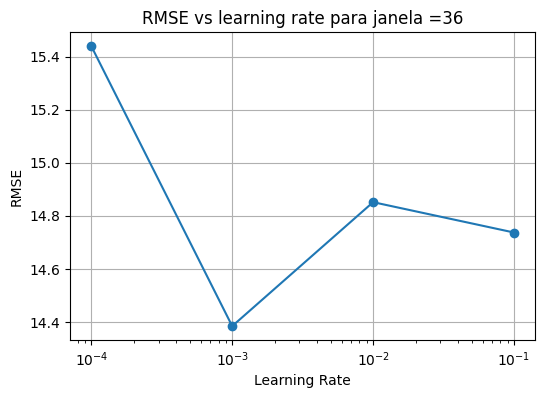

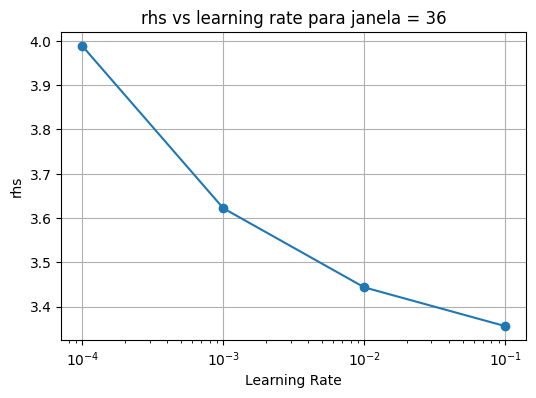

In [147]:
# ------------------------------------------------------------------
# 4.  Visualização rápida
# ------------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(results_df_win["lr"], results_df_win["rmse"], marker="o")
plt.title(f"RMSE vs learning rate para janela ={results_df_win.window_size.values[0]}")
plt.xlabel("Learning Rate") # Changed xlabel to be more accurate
plt.ylabel("RMSE")
plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(results_df_win["lr"], results_df_win["rhs"], marker="o")
plt.title(f"rhs vs learning rate para janela = {results_df_win.window_size.values[0]}")
plt.xlabel("Learning Rate") # Changed xlabel to be more accurate
plt.ylabel("rhs")
plt.xscale('log')
plt.grid(True)
plt.show()

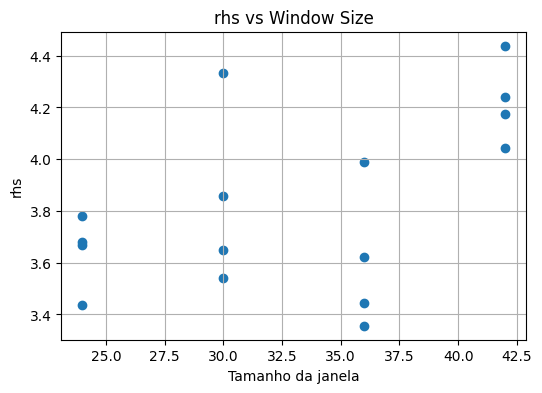

In [155]:
# ------------------------------------------------------------------
# 5.  Visualização rápida
# ------------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(results_df["window_size"], results_df["rhs"], marker="o",label=results_df["lr"].unique)
plt.title("rhs vs Window Size")
plt.xlabel("Tamanho da janela")
plt.ylabel("rhs")
# plt.legend()
plt.grid(True)
plt.show()

In [164]:
X_all, y_all, X_test, y_test = build_matrices(24,SENSOR_SETS)
rmse, rhs = train_full_and_test(X_all, y_all, X_test, y_test, lr=1e-3)
print(rmse, rhs)

KeyError: "None of [Index(['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15',\n       's17', 's20', 's21'],\n      dtype='object')] are in the [columns]"